# 1. CatBoost Ranking on LETOR


In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from catboost import CatBoostRanker, Pool
from catboost.utils import eval_metric

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Данные MQ2008

Используем `MQ2008` из `LETOR 4.0`.

В `MQ2008` каждая строка соответствует паре `запрос-документ`.
В начале строки стоит метка релевантности, потом `qid` запроса, дальше идут 46 признаков, по которым модель учится ранжировать документы внутри одного запроса.

В папках `Fold1` ... `Fold5` уже лежит готовое разбиение на `train`, `vali` и `test`.
Эти файлы построены на нормализованной версии датасета, поэтому значения признаков уже числовые и их можно сразу подавать в CatBoost.




In [5]:
DATA_ROOT = Path.cwd().parent / "data" / "MQ2008"
FOLDS = [1, 2, 3, 4, 5]
TOP_K = 10


def parse_letor_file(path: Path):
    X, y, group_id = [], [], []

    with path.open() as source:
        for line in source:
            line = line.split("#", 1)[0].strip()
            if not line:
                continue

            parts = line.split()
            y.append(float(parts[0]))
            group_id.append(int(parts[1].split(":", 1)[1]))
            X.append([float(token.split(":", 1)[1]) for token in parts[2:]])

    return {
        "X": np.array(X, dtype=np.float32),
        "y": np.array(y, dtype=np.float32),
        "group_id": np.array(group_id, dtype=np.int64),
    }


def load_fold(fold: int):
    fold_dir = DATA_ROOT / f"Fold{fold}"
    return {
        "train": parse_letor_file(fold_dir / "train.txt"),
        "vali": parse_letor_file(fold_dir / "vali.txt"),
        "test": parse_letor_file(fold_dir / "test.txt"),
    }


fold_data = {fold: load_fold(fold) for fold in FOLDS}


In [112]:
overview_by_fold = pd.DataFrame(
    {
        f"Fold{i} train": pd.Series(
            {
                "Число документов": fold_data[i]["train"]["X"].shape[0],
                "Число признаков": fold_data[i]["train"]["X"].shape[1],
                "Число запросов": np.unique(fold_data[i]["train"]["group_id"]).shape[0],
                "Релевантность 0": (fold_data[i]["train"]["y"].astype(int) == 0).sum(),
                "Релевантность 1": (fold_data[i]["train"]["y"].astype(int) == 1).sum(),
                "Релевантность 2": (fold_data[i]["train"]["y"].astype(int) == 2).sum(),
            }
        )
        for i in FOLDS
    }
)

overview_by_fold.style.format("{:.0f}")


,Fold1 train,Fold2 train,Fold3 train,Fold4 train,Fold5 train
Число документов,9630,9404,8643,8514,9442
Число признаков,46,46,46,46,46
Число запросов,471,471,470,470,470
Релевантность 0,7820,7644,6883,6775,7715
Релевантность 1,1223,1196,1189,1205,1190
Релевантность 2,587,564,571,534,537


In [113]:
mq2008_full = parse_letor_file(DATA_ROOT / "Querylevelnorm.txt")

pd.Series(
    {
        "Всего документов": mq2008_full["X"].shape[0],
        "Всего признаков": mq2008_full["X"].shape[1],
        "Всего запросов": np.unique(mq2008_full["group_id"]).shape[0],
        "Релевантность 0": (mq2008_full["y"].astype(int) == 0).sum(),
        "Релевантность 1": (mq2008_full["y"].astype(int) == 1).sum(),
        "Релевантность 2": (mq2008_full["y"].astype(int) == 2).sum(),
    }
).to_frame("MQ2008 full").style.format("{:.0f}")


,MQ2008 full
Всего документов,15211
Всего признаков,46
Всего запросов,784
Релевантность 0,12279
Релевантность 1,2001
Релевантность 2,931


## Метрики

Будем считать `Precision@10`, `MAP@10` и `NDCG@10`:

Для `NDCG@10` используем исходные метки релевантности.

Для `Precision@10` и `MAP@10` считаем документ релевантным, если `label > 0`.


In [19]:
METRIC_NAMES = {
    f"Precision@{TOP_K}": f"PrecisionAt:top={TOP_K}",
    f"MAP@{TOP_K}": f"MAP:top={TOP_K}",
    f"NDCG@{TOP_K}": f"NDCG:top={TOP_K}",
}


def evaluate_ranking(y_true: np.ndarray, scores: np.ndarray, group_id: np.ndarray):
    y_binary = (y_true > 0).astype(int)

    return {
        f"Precision@{TOP_K}": eval_metric(y_binary, scores, METRIC_NAMES[f"Precision@{TOP_K}"], group_id=group_id)[0],
        f"MAP@{TOP_K}": eval_metric(y_binary, scores, METRIC_NAMES[f"MAP@{TOP_K}"], group_id=group_id)[0],
        f"NDCG@{TOP_K}": eval_metric(y_true, scores, METRIC_NAMES[f"NDCG@{TOP_K}"], group_id=group_id)[0],
    }


## Модели

Сравниваем основные ranking-loss функции из tutorial:
- `RMSE`
- `QueryRMSE`
- `PairLogit`
- `PairLogitPairwise`
- `YetiRank`
- `YetiRankPairwise`


In [90]:
LOSSES_TO_RUN = [
    "RMSE",
    "QueryRMSE",
    "PairLogit",
    "PairLogitPairwise",
    "YetiRank",
    "YetiRankPairwise",
]


def make_pool(split):
    return Pool(split["X"], split["y"], group_id=split["group_id"])


def run_single_experiment(
    loss_name: str,
    fold: int,
    common_params: dict,
    exp_name: str = "initial",
    data: dict = fold_data,
):
    split_data = data[fold]

    train_pool = make_pool(split_data["train"])
    vali_pool = make_pool(split_data["vali"])
    test_pool = make_pool(split_data["test"])

    params = common_params | {"loss_function": loss_name}

    model_dir = Path.cwd() / "models" / exp_name
    model_dir.mkdir(parents=True, exist_ok=True)

    model_name = f"{loss_name.lower()}_fold_{fold}.cbm"
    model_path = model_dir / model_name

    if model_path.exists():
        model = CatBoostRanker()
        model.load_model(model_path)
        fit_time_sec = 0.0
    else:
        start_time = time.perf_counter()
        model = CatBoostRanker(**params)
        model.fit(train_pool, eval_set=vali_pool)
        fit_time_sec = time.perf_counter() - start_time
        model.save_model(model_path)

    test_scores = model.predict(test_pool)
    metrics = evaluate_ranking(
        split_data["test"]["y"],
        test_scores,
        split_data["test"]["group_id"],
    )

    best_iteration = model.get_best_iteration()
    if best_iteration is None:
        best_iteration = params["iterations"]

    return {
        "loss": loss_name,
        "fold": fold,
        **metrics,
        "best_iteration": int(best_iteration),
        "fit_time_sec": fit_time_sec,
    }


In [91]:
COMMON_PARAMS = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 8,
    "random_seed": 42,
    "eval_metric": f"NDCG:top={TOP_K}",
    "use_best_model": True,
    "od_type": "Iter",
    "od_wait": 100,
    "thread_count": -1,
    "allow_writing_files": False,
    "verbose": False,
}

exp_name = "letor_depth8_lr005"

results = []

for loss_name in LOSSES_TO_RUN:
    for fold in FOLDS:
        row = run_single_experiment(loss_name, fold, COMMON_PARAMS, exp_name)
        results.append(row)
        print(
            f"{loss_name:>18} | Fold {fold} | "
            f"Precision@10={row['Precision@10']:.4f} | "
            f"MAP@10={row['MAP@10']:.4f} | "
            f"NDCG@10={row['NDCG@10']:.4f} | "
            f"best_iter={row['best_iteration']} | "
            f"time={row['fit_time_sec']:.1f}s"
        )

results_df = pd.DataFrame(results)

              RMSE | Fold 1 | Precision@10=0.2694 | MAP@10=0.4457 | NDCG@10=0.8218 | best_iter=73 | time=0.0s
              RMSE | Fold 2 | Precision@10=0.2457 | MAP@10=0.4091 | NDCG@10=0.7909 | best_iter=13 | time=0.0s
              RMSE | Fold 3 | Precision@10=0.2557 | MAP@10=0.4332 | NDCG@10=0.7823 | best_iter=197 | time=0.0s
              RMSE | Fold 4 | Precision@10=0.3232 | MAP@10=0.4856 | NDCG@10=0.7779 | best_iter=3 | time=0.0s
              RMSE | Fold 5 | Precision@10=0.2793 | MAP@10=0.4829 | NDCG@10=0.7805 | best_iter=32 | time=0.0s
         QueryRMSE | Fold 1 | Precision@10=0.2662 | MAP@10=0.4467 | NDCG@10=0.8215 | best_iter=262 | time=0.0s
         QueryRMSE | Fold 2 | Precision@10=0.2502 | MAP@10=0.4197 | NDCG@10=0.7968 | best_iter=68 | time=0.0s
         QueryRMSE | Fold 3 | Precision@10=0.2563 | MAP@10=0.4230 | NDCG@10=0.7761 | best_iter=7 | time=0.0s
         QueryRMSE | Fold 4 | Precision@10=0.3283 | MAP@10=0.5003 | NDCG@10=0.7863 | best_iter=20 | time=0.0s
         Q

In [92]:
summary = (
    results_df
    .groupby("loss", as_index=True)
    .agg(
        PrecisionAt10=("Precision@10", "mean"),
        MAPAt10=("MAP@10", "mean"),
        NDCGAt10=("NDCG@10", "mean"),
    )
).reindex(LOSSES_TO_RUN)

summary

,PrecisionAt10,MAPAt10,NDCGAt10
loss,,,
RMSE,0.2747,0.4513,0.7907
QueryRMSE,0.2758,0.4561,0.7936
PairLogit,0.2724,0.4500,0.7906
PairLogitPairwise,0.2739,0.4498,0.7883
YetiRank,0.2727,0.4529,0.7913
YetiRankPairwise,0.2752,0.4541,0.7913


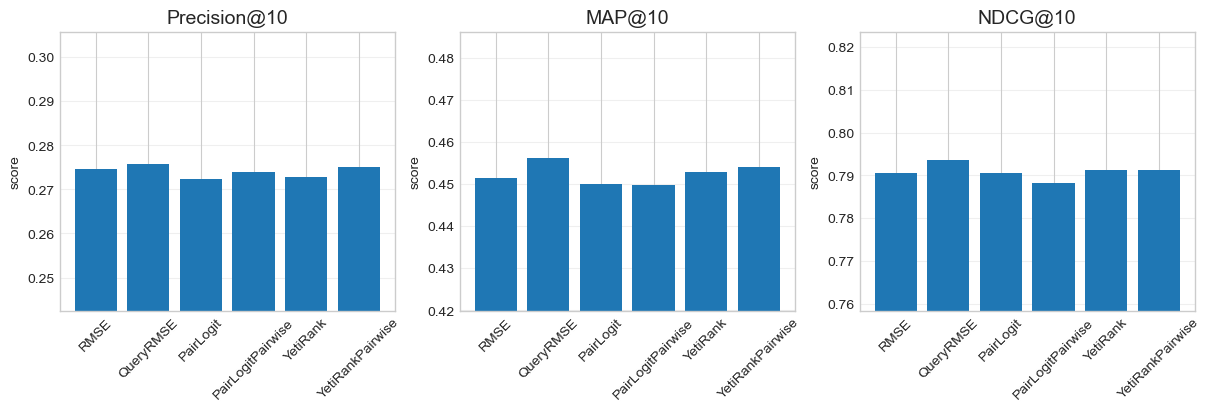

In [93]:
summary_plot = summary.reindex(LOSSES_TO_RUN)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

plot_config = [
    ("PrecisionAt10", f"Precision@{TOP_K}"),
    ("MAPAt10", f"MAP@{TOP_K}"),
    ("NDCGAt10", f"NDCG@{TOP_K}"),
]

for ax, (col, title) in zip(axes, plot_config):
    values = summary_plot[col]
    ymin = max(0, values.min() - 0.03)
    ymax = min(1, values.max() + 0.03)

    ax.bar(summary_plot.index, values)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("score")
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45, labelsize=10)

plt.show()


# 2. Learning to Rank on Internet Math 2009


## 2.1 Приведение к LETOR-формату

Файлы `imat2009_train_new.txt` и `imat2009_test_new.txt` уже почти имеют формат LETOR.

В начале строки стоит метка релевантности, дальше идут признаки, а номер запроса записан после символа `#`.
Поэтому достаточно взять это число после `#` и использовать его как `qid`.


In [82]:
IMAT_RAW_DIR = Path.cwd().parent / "data" / "imat2009_new_split"
IMAT_NUM_FEATURES = 245


def load_imat(path, num_features=245):
    X, y, group_id = [], [], []

    with open(path) as source:
        for line in source:
            left, qid = line.rsplit("#", 1)
            parts = left.split()

            y.append(float(parts[0]))
            group_id.append(int(qid.strip()))

            row = np.zeros(num_features, dtype=np.float32)
            for token in parts[1:]:
                idx, value = token.split(":")
                row[int(idx) - 1] = float(value)
            X.append(row)

    return {
        "X": np.array(X, dtype=np.float32),
        "y": np.array(y, dtype=np.float32),
        "group_id": np.array(group_id, dtype=np.int64),
    }


imat_data = {
    "train_full": load_imat(IMAT_RAW_DIR / "imat2009_train_new.txt", IMAT_NUM_FEATURES),
    "test": load_imat(IMAT_RAW_DIR / "imat2009_test_new.txt", IMAT_NUM_FEATURES),
}


In [84]:
def describe_imat_split(split):
    group_sizes = pd.Series(split["group_id"]).value_counts()
    nonzero_per_doc = np.count_nonzero(split["X"], axis=1)

    return pd.Series(
        {
            "Число документов": split["X"].shape[0],
            "Число признаков": split["X"].shape[1],
            "Число запросов": group_sizes.shape[0],
            "Среднее число документов на запрос": group_sizes.mean(),
            "Максимум документов на запрос": group_sizes.max(),
            "Среднее число ненулевых признаков": nonzero_per_doc.mean(),
            "Уникальных меток": np.unique(split["y"]).shape[0],
            "Процент нулевой релевантности": (split["y"] == 0).mean() * 100,
        }
    )


imat_overview = pd.DataFrame(
    {name: describe_imat_split(split) for name, split in imat_data.items()}
)

imat_overview.style.format("{:.0f}")

,train_full,test
Число документов,77714,19576
Число признаков,245,245
Число запросов,7300,1824
Среднее число документов на запрос,11,11
Максимум документов на запрос,461,434
Среднее число ненулевых признаков,123,126
Уникальных меток,71,48
Процент нулевой релевантности,33,33


Дополнительно выделим валидационную выборку из обучающей части.
Разбиение будем делать по запросам, чтобы документы одного и того же запроса не попадали одновременно в `train` и `vali`.

In [94]:
VALI_SHARE = 0.1
RANDOM_SEED = 42

qids = np.unique(imat_data["train_full"]["group_id"])
vali_size = int(len(qids) * VALI_SHARE)

rng = np.random.default_rng(RANDOM_SEED)
vali_qids = set(rng.choice(qids, size=vali_size, replace=False))

train_mask = np.array(
    [qid not in vali_qids for qid in imat_data["train_full"]["group_id"]]
)
vali_mask = ~train_mask

imat_data["train"] = {
    key: values[train_mask]
    for key, values in imat_data["train_full"].items()
}
imat_data["vali"] = {
    key: values[vali_mask]
    for key, values in imat_data["train_full"].items()
}

imat_data.keys()

dict_keys(['train_full', 'test', 'train', 'vali'])

## 2.2 Эксперименты

Целевая метрика — `NDCG@10`, но дополнительно сохраним `Precision@10` и `MAP@10`.


In [106]:
IMAT_LOSSES = [
    "RMSE",
    "QueryRMSE",
    "PairLogit",
    "PairLogitPairwise",
    "YetiRank",
    "YetiRankPairwise",
]


IMAT_COMMON_PARAMS = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 8,
    "random_seed": 42,
    "eval_metric": f"NDCG:top={TOP_K}",
    "use_best_model": True,
    "od_type": "Iter",
    "od_wait": 100,
    "thread_count": -1,
    "allow_writing_files": False,
    "verbose": False,
}

imat_fold_data = {
    0: {
        "train": imat_data["train"],
        "vali": imat_data["vali"],
        "test": imat_data["test"],
    }
}

In [107]:
imat_exp_name = "imat_depth8_lr005"

imat_results = []

for loss_name in IMAT_LOSSES:
    row = run_single_experiment(
        loss_name=loss_name,
        fold=0,
        common_params=IMAT_COMMON_PARAMS,
        exp_name=imat_exp_name,
        data=imat_fold_data,
    )
    imat_results.append(row)

    print(
        f"{loss_name:>18} | "
        f"Precision@10={row['Precision@10']:.4f} | "
        f"MAP@10={row['MAP@10']:.4f} | "
        f"NDCG@10={row['NDCG@10']:.4f} | "
        f"best_iter={row['best_iteration']} | "
        f"time={row['fit_time_sec']:.1f}s"
    )

imat_results_df = pd.DataFrame(imat_results)

              RMSE | Precision@10=0.6210 | MAP@10=0.7457 | NDCG@10=0.8715 | best_iter=321 | time=0.0s
         QueryRMSE | Precision@10=0.6218 | MAP@10=0.7469 | NDCG@10=0.8732 | best_iter=554 | time=0.0s
         PairLogit | Precision@10=0.6210 | MAP@10=0.7454 | NDCG@10=0.8719 | best_iter=288 | time=29.2s
 PairLogitPairwise | Precision@10=0.6218 | MAP@10=0.7455 | NDCG@10=0.8701 | best_iter=179 | time=487.7s
          YetiRank | Precision@10=0.6224 | MAP@10=0.7467 | NDCG@10=0.8726 | best_iter=345 | time=0.0s
  YetiRankPairwise | Precision@10=0.6213 | MAP@10=0.7445 | NDCG@10=0.8687 | best_iter=388 | time=520.5s


In [108]:
imat_summary = (
    imat_results_df
    .set_index("loss")[["Precision@10", "MAP@10", "NDCG@10"]]
    .rename(
        columns={
            "Precision@10": "PrecisionAt10",
            "MAP@10": "MAPAt10",
            "NDCG@10": "NDCGAt10",
        }
    )
    .reindex(IMAT_LOSSES)
)

imat_summary


,PrecisionAt10,MAPAt10,NDCGAt10
loss,,,
RMSE,0.6210,0.7457,0.8715
QueryRMSE,0.6218,0.7469,0.8732
PairLogit,0.6210,0.7454,0.8719
PairLogitPairwise,0.6218,0.7455,0.8701
YetiRank,0.6224,0.7467,0.8726
YetiRankPairwise,0.6213,0.7445,0.8687


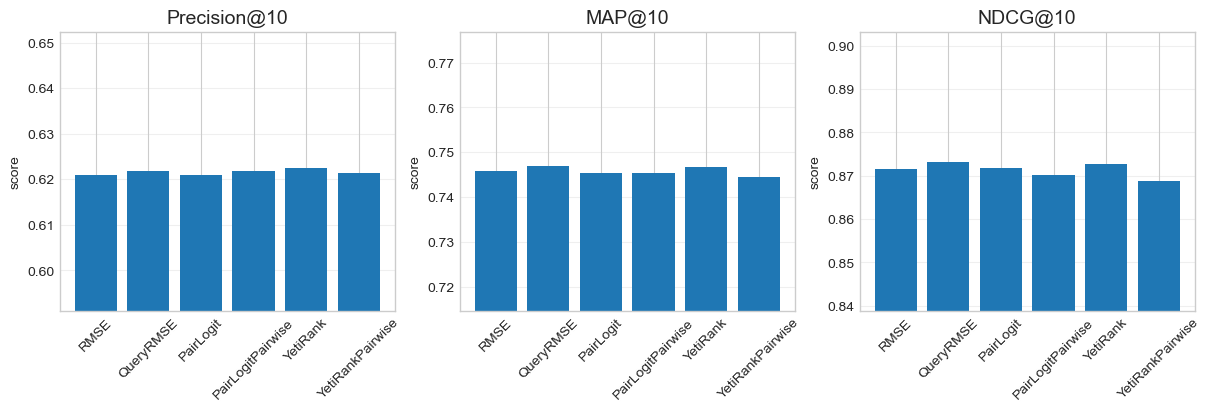

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

plot_config = [
    ("PrecisionAt10", f"Precision@{TOP_K}"),
    ("MAPAt10", f"MAP@{TOP_K}"),
    ("NDCGAt10", f"NDCG@{TOP_K}"),
]

for ax, (col, title) in zip(axes, plot_config):
    values = imat_summary[col]
    ymin = max(0, values.min() - 0.03)
    ymax = min(1, values.max() + 0.03)

    ax.bar(imat_summary.index, values)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("score")
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45, labelsize=10)

plt.show()
